# `shop.py`

```python
from robot.api.deco import library, keyword
from robot.libraries.BuiltIn import BuiltIn


@library
class Shop:
    selenium_lib = None

    def __init__(self):
        # BuiltIn class allows accessing Robot Framework libraries
        self.selenium_lib = BuiltIn().get_library_instance("SeleniumLibrary")

    # method name will be converter to keyword
    @keyword
    def hello_world(self):
        print("Hello World!!")

    @keyword
    def add_items_to_cart_and_checkout(self, product_list):

        # Get WebElements   css:.card-title
        product_titles = self.selenium_lib.get_webelements("css:.card-title")

        i = 1
        for product in product_titles:
            if product.text in product_list:
                self.selenium_lib.click_button(f"xpath:(//*[@class='card-footer'])[{i}]/button")
            i = i + 1
```

# `landing_page.robot`

```
*** Settings ***
Documentation    All the page objects and keywords of the Landing Page.
Library    SeleniumLibrary

*** Keywords ***

Fill the login form
    [arguments]           ${username}    ${password}
    Wait Until Element Is Visible    username
    Input Text            id:username    ${username}
    Input Password        id:password    ${password}
    Click Button          signInBtn
```

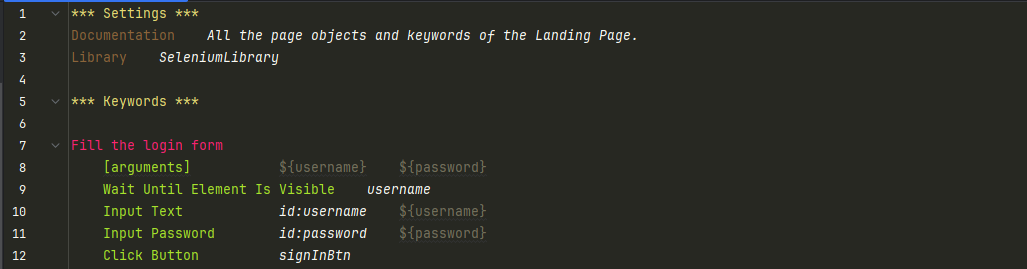

# `shop_page.robot`

```
*** Settings ***
Documentation    All the page objects and keywords of the Shop Page.
Library    SeleniumLibrary

*** Variables ***
${checkout_button_locator}     css:.nav-link

*** Keywords ***

Wait until element is located in the page
    [arguments]                           ${checkout_button_locator}
    Wait Until Element Is Visible         ${checkout_button_locator}

Verify card titles in the shopping page
    # List variable
    @{expected_list}=    Create List    iphone X    Samsung Note 8    Nokia Edge    Blackberry

    # Retrieve list of web elements
    @{elements}=    Get Webelements       css:.card-title

    # actual list
    @{actual_list}=    Create List

    # For Loop
    FOR    ${element}  IN    @{elements}
        ${text}=    Get Text    ${element}
        Log    ${text}
        Append To List    ${actual_list}    ${text}
    END

    # Compare expected & actual list
    Lists Should Be Equal    ${expected_list}    ${actual_list}
```

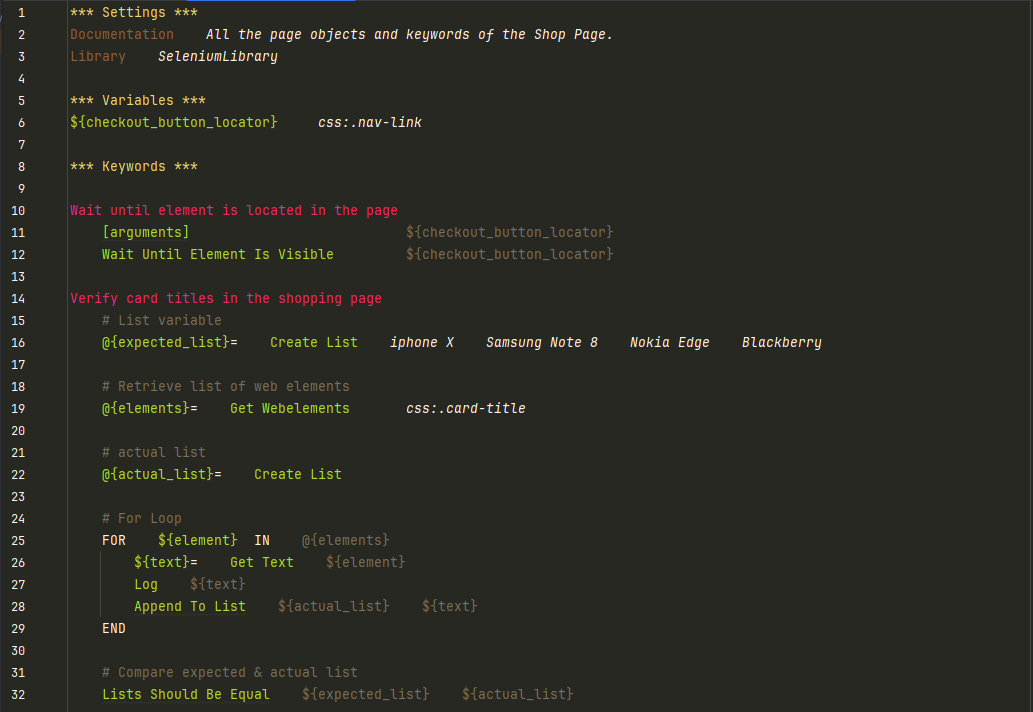

# `page_objects_demo.robot`

```
*** Settings ***
Documentation        To validate custom keyword
Library              SeleniumLibrary                                    
Library              Collections
Library              ../custom_library/shop.py
# Suite Setup
# Suite Teardown
Test Setup           open the browser with the mortgage payment url     
Test Teardown        Close Browser                                      
Resource             resource.robot
Resource             ../pageobjects/landing_page.robot
Resource             ../pageobjects/shop_page.robot

*** Variables ***
@{list_of_products}            Blackberry    Nokia Edge

*** Test Cases ***

Validate cards display in the shopping list
    landing_page.Fill the login form                         ${user_name}    ${valid_password}
    shop_page.Wait until element is located in the page      ${checkout_button_locator}
    shop_page.Verify card titles in the shopping page
    Add Items To Cart And Checkout                           ${list_of_products}
```

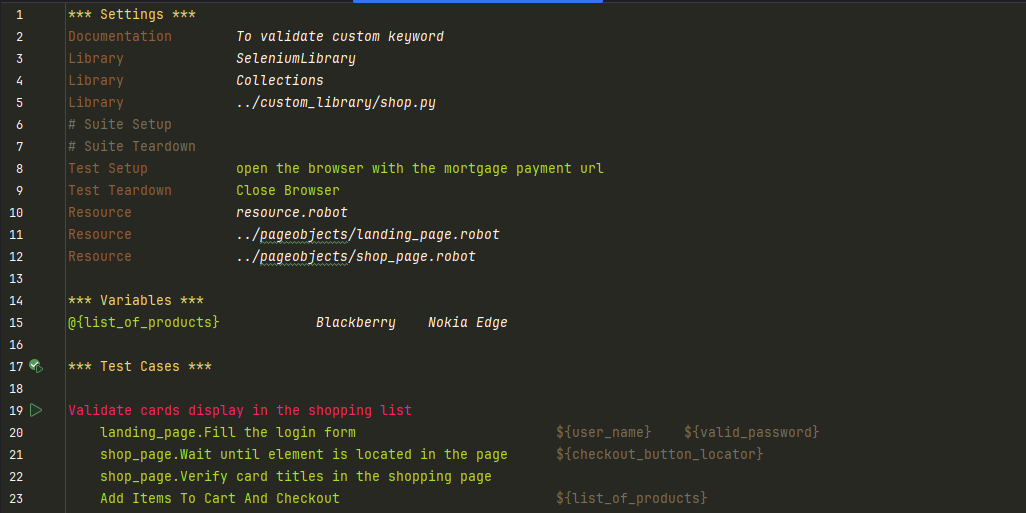